In [1]:
from scapy.all import rdpcap, TCP
import pandas as pd

In [2]:
# Load the pcap file
packets = rdpcap(r"C:\Users\saint\OneDrive\Documents\ClientServerHW\CapturePackets.pcapng")  

In [4]:
 # Extract relevant features from TCP packets
packet_data = []
for pkt in packets:
    if pkt.haslayer(TCP) and pkt.haslayer('IP'):  # Focus only on TCP packets
        packet_data.append({
            'Source': pkt['IP'].src,
            'Destination': pkt['IP'].dst,
            'Protocol': 'TCP',
            'Packet Length': len(pkt),
            'Timestamp': pkt.time
        })

In [5]:
# Convert to a DataFrame
df = pd.DataFrame(packet_data)
print("Extracted TCP Packet Data:")
print(df.head())

Extracted TCP Packet Data:
          Source    Destination Protocol  Packet Length          Timestamp
0  123.204.1.197    192.123.1.1      TCP             66  1734468509.568721
1  154.128.1.167    192.135.1.1      TCP             66  1734468509.568885
2    132.130.1.1  192.168.1.173      TCP             66  1734468509.575903
3    102.172.1.6  192.171.1.183      TCP             66  1734468509.575903
4  102.188.4.167    192.146.1.1      TCP             54  1734468509.576146


In [6]:
# Save to CSV for further processing
df.to_csv("tcp_packet_data.csv", index=False)

In [7]:
from sklearn.preprocessing import StandardScaler
import hashlib

In [8]:
# Load TCP packet data
df = pd.read_csv("tcp_packet_data.csv")

In [9]:
# Encode IP addresses using hashing
df['Source'] = df['Source'].apply(lambda x: int(hashlib.md5(x.encode()).hexdigest(), 16) % 10**8)
df['Destination'] = df['Destination'].apply(lambda x: int(hashlib.md5(x.encode()).hexdigest(), 16) % 10**8)

In [10]:
# Select features and standardize
features = ['Source', 'Destination', 'Packet Length']
scaler = StandardScaler()
X = scaler.fit_transform(df[features])

In [11]:
print("Preprocessed Data (First 5 Rows):")
print(X[:5])

Preprocessed Data (First 5 Rows):
[[-0.03846188  0.39494923 -0.25184057]
 [-0.03846188  0.39494923 -0.25184057]
 [ 0.29607053  0.01414707 -0.25184057]
 [ 0.29607053  0.01414707 -0.25184057]
 [-0.03846188  0.39494923 -0.26038741]]


In [12]:
# Step 3: Anomaly Detection Using KMeans

In [14]:
from sklearn.cluster import KMeans
import numpy as np
import matplotlib.pyplot as plt

In [15]:
# Apply KMeans clustering
kmeans = KMeans(n_clusters=2, random_state=42)  # Assume 2 clusters: normal and anomalous
df['Cluster'] = kmeans.fit_predict(X)

In [16]:
# Compute distance to cluster centers
distances = kmeans.transform(X).min(axis=1)
threshold = np.percentile(distances, 95)  # 95th percentile as anomaly threshold
df['Anomaly'] = distances > threshold


In [17]:
# Display results
print(f"Number of anomalies detected: {df['Anomaly'].sum()}")
print(df[df['Anomaly']])

Number of anomalies detected: 88
        Source  Destination Protocol  Packet Length     Timestamp  Cluster  \
25    55305822      1177113      TCP             54  1.734469e+09        0   
26    55305822      1177113      TCP             85  1.734469e+09        0   
29    55305822      1177113      TCP             54  1.734469e+09        0   
208   25540421     55305822      TCP           4434  1.734469e+09        0   
231   31528732     55305822      TCP           4236  1.734469e+09        0   
...        ...          ...      ...            ...           ...      ...   
1798  55305822      1177113      TCP             54  1.734469e+09        0   
1800  55305822      1177113      TCP             66  1.734469e+09        0   
1807  55305822      1177113      TCP             54  1.734469e+09        0   
1808  55305822      1177113      TCP             85  1.734469e+09        0   
1814  55305822      1177113      TCP             82  1.734469e+09        0   

      Anomaly  
25       True 

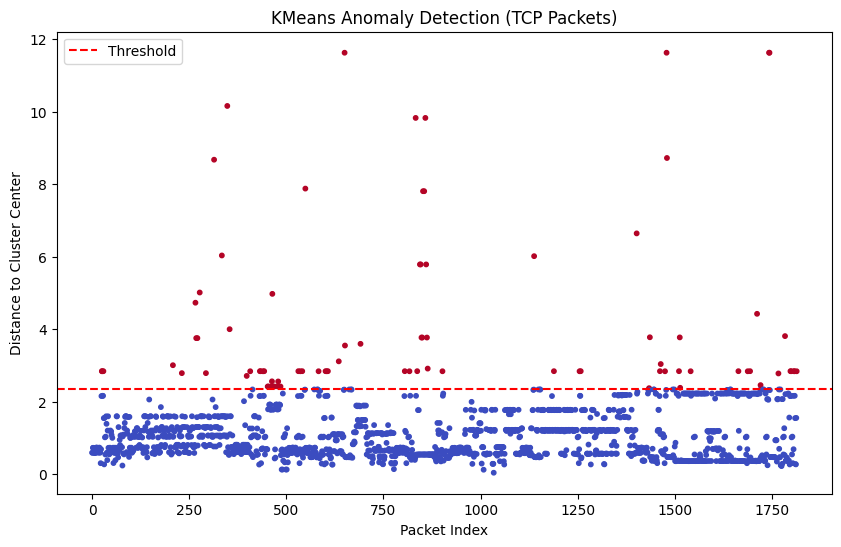

In [18]:
# Visualization
plt.figure(figsize=(10, 6))
plt.scatter(range(len(distances)), distances, c=df['Anomaly'], cmap='coolwarm', s=10)
plt.axhline(y=threshold, color='r', linestyle='--', label='Threshold')
plt.title("KMeans Anomaly Detection (TCP Packets)")
plt.xlabel("Packet Index")
plt.ylabel("Distance to Cluster Center")
plt.legend()
plt.show()

In [19]:
# Step 4: Train a Random Forest Classifier

In [20]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix


In [21]:
# Label anomalies as 1 (malicious), others as 0
df['Label'] = df['Anomaly'].astype(int)

In [22]:
# Prepare features and target
X = df[['Source', 'Destination', 'Packet Length']]
y = df['Label']

In [23]:
# Split into training and testing data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [24]:
# Train Random Forest Classifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)


RandomForestClassifier(random_state=42)

In [25]:
# Evaluate the model
y_pred = rf_model.predict(X_test)
print("Classification Report:")
print(classification_report(y_test, y_pred))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       515
           1       1.00      0.97      0.98        30

    accuracy                           1.00       545
   macro avg       1.00      0.98      0.99       545
weighted avg       1.00      1.00      1.00       545

Confusion Matrix:
[[515   0]
 [  1  29]]


In [26]:
# Step 5: Visualize Results

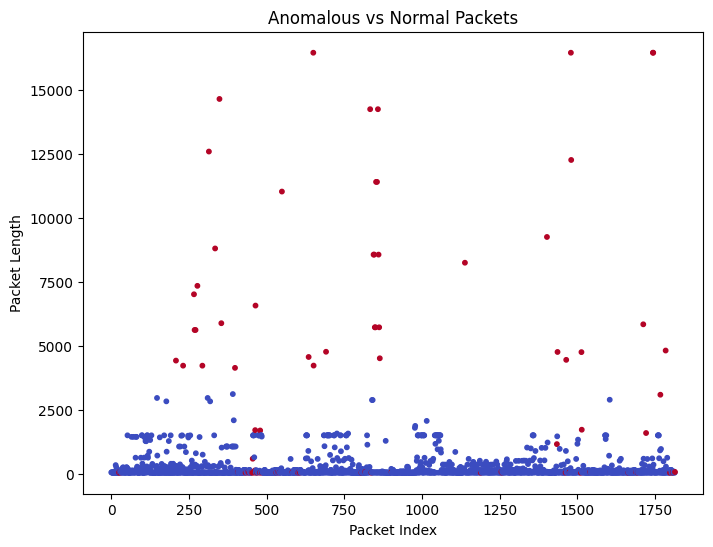

In [27]:
plt.figure(figsize=(8, 6))
plt.scatter(df.index, df['Packet Length'], c=df['Anomaly'], cmap='coolwarm', s=10)
plt.title("Anomalous vs Normal Packets")
plt.xlabel("Packet Index")
plt.ylabel("Packet Length")
plt.show()

In [28]:
# Step 6: Predict on New Packet Data

In [29]:
# Simulated new TCP packet
new_packet = pd.DataFrame({
    'Source': [int(hashlib.md5("322.238.1.30".encode()).hexdigest(), 16) % 10**8],
    'Destination': [int(hashlib.md5("11.1.1.1".encode()).hexdigest(), 16) % 10**8],
    'Packet Length': [700]
})

# Predict if the packet is anomalous
prediction = rf_model.predict(new_packet)
print("New Packet Classification:", "Malicious" if prediction[0] == 1 else "Normal")

New Packet Classification: Normal
